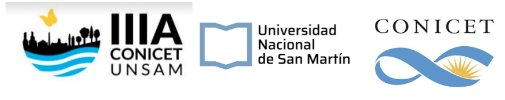  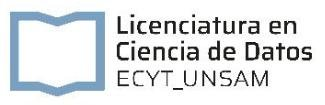

---

# NB02 — Índices espectrales, georeferenciación y análisis temporal

Lo que veremos en esta notebook:

- [x] Sistemas de referencia de coordenadas (CRS): EPSG, WGS84, UTM
- [x] La geotransformación: de píxeles a coordenadas reales
- [x] Recorte por slicing y recálculo de la geotransformación
- [x] Recorte por polígono vectorial con Rasterio
- [x] Álgebra de bandas e índices espectrales: NDVI, NDWI
- [x] Composición RGB de índices: interpretar el color como información
- [x] Escritura de GeoTIFFs con nombres de banda
- [x] Diseño temporal: cómo separar variación estacional de cambio real
---

### Objetivos de la notebook

Al terminar esta clase esperamos que puedas:

- Entender qué es un CRS y cómo se expresa en Rasterio.
- Interpretar la geotransformación y calcular recortes con slicing.
- Recortar una imagen satelital con un polígono vectorial.
- Calcular índices espectrales y componer RGB para interpretarlos.
- Diseñar correctamente una comparación temporal entre imágenes.
- Guardar resultados como GeoTIFF con nombres de banda.

### Datos con los que trabajaremos

Tres imágenes Sentinel-2 del recorte Moreno / Reconquista, tile T21HUB, nivel L2A:

| Archivo | Fecha | Estación | Rol en el análisis |
|---|---|---|---|
| `S2_moreno_B02B03B04B08_2026feb.tif` | Febrero 2026 | Verano | Referencia reciente |
| `S2_moreno_B02B03B04B08_2025ago.tif` | Agosto 2025 | Invierno | Par estacional de 2026feb |
| `S2_moreno_B02B03B04B08_2015ago.tif` | Agosto 2015 | Invierno | Par temporal de 2025ago |

Este diseño de tres imágenes nos permite **separar dos fuentes de variación** que de otro modo se confunden:

- **Variación estacional:** comparando 2025ago ↔ 2026feb vemos el efecto de la estación sobre el *mismo* territorio.
- **Cambio real del territorio:** comparando 2015ago ↔ 2025ago vemos transformaciones reales sobre la *misma* estación.

La comparación directa 2015ago ↔ 2026feb mezcla ambos efectos y no permite interpretar qué causó qué. La usamos al final de esta notebook solo para ilustrar ese problema metodológico.

### El arco del curso

Esta notebook introduce los índices con los que vamos a trabajar durante todo el cuatrimestre. En clases posteriores vamos a clasificar el territorio usando estas mismas variables, detectar cambios entre 2015 y 2025, y relacionar esos cambios con la vulnerabilidad social del territorio.

La pregunta que guía el curso: ***¿Existe una isla de calor urbana en el oeste del AMBA, cómo se relaciona con la pérdida de cobertura vegetal y quiénes son los que la sufren más?***

---
# 0. Bibliotecas

En esta notebook vamos a guardar imágenes y es por eso que necesitamos incorporar la siguiente función a la biblioteca **`ade_tools.py`**
```python
def guardar_geotiff(fn, array, perfil_referencia, nodata=None, nombres_bandas=None):
    """
    Guarda un array como GeoTIFF georeferenciado con nombres de banda opcionales.
    """
    if os.path.dirname(fn):
        os.makedirs(os.path.dirname(fn), exist_ok=True)
    if array.ndim == 2:
        array = array[np.newaxis, :, :]
    perfil = perfil_referencia.copy()
    perfil.update({
        'driver': 'GTiff', 'dtype': array.dtype,
        'count': array.shape[0], 'height': array.shape[1], 'width': array.shape[2],
    })
    if nodata is not None:
        perfil['nodata'] = nodata
    with rasterio.open(fn, 'w', **perfil) as dst:
        dst.write(array)
        if nombres_bandas:
            for i, nombre in enumerate(nombres_bandas):
                dst.set_band_description(i + 1, nombre)
    print(f'Guardado: {fn}  ({array.shape[1]}×{array.shape[2]} px, {array.shape[0]} banda/s)')
```

---
> **`guardar_geotiff()` → `ade_tools.py`**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.mask import mask as rasterio_mask
from rasterio.transform import Affine
import geopandas as gpd

from ade_tools import escalar, componer_rgb, ecualizar_rgb, guardar_geotiff

RAW  = 'data/raw_data/'
PROC = 'data/proc/'
OUT  = 'data/out/'

FN_2026FEB = RAW + 'satelital/S2_moreno_B02B03B04B08_2026feb.tif'
FN_2025AGO = RAW + 'satelital/S2_moreno_B02B03B04B08_2025ago.tif'
FN_2015AGO = RAW + 'satelital/S2_moreno_B02B03B04B08_2015ago.tif'

---
# 1. Sistemas de referencia de coordenadas (CRS)

## 1.1 El problema de representar la Tierra en un plano

La Tierra es aproximadamente esférica. Una imagen satelital es un plano. Para pasar de una a otra necesitamos una **proyección cartográfica** que convierte coordenadas sobre la superficie curva (latitud/longitud) en coordenadas sobre un plano (x/y en metros). Toda proyección distorsiona algo.

## 1.2 WGS84 y UTM

**WGS84 (EPSG:4326)** — el sistema geográfico global del GPS. Coordenadas en grados decimales. No proyectado. Sistema nativo de los archivos GeoJSON.

**UTM** (*Universal Transversal Mercator*) — 60 fajas de 6° de longitud. Dentro de cada faja la proyección minimiza distorsión angular. Coordenadas en **metros**: permite calcular distancias y áreas directamente.

Nuestro recorte está en **zona UTM 21S** → código **EPSG:32721**.

In [ ]:
with rasterio.open(FN_2026FEB) as src:
    crs    = src.crs
    bounds = src.bounds
    T      = src.transform
    alto, ancho = src.shape

print('CRS           :', crs)
print('EPSG          :', crs.to_epsg())
print()
print('Bounds (metros UTM):')
print(f'  xmin: {bounds.left:>13.1f} m')
print(f'  xmax: {bounds.right:>13.1f} m')
print(f'  ymin: {bounds.bottom:>13.1f} m')
print(f'  ymax: {bounds.top:>13.1f} m')
print(f'\nExtensión: {(bounds.right-bounds.left)/1000:.1f} km × {(bounds.top-bounds.bottom)/1000:.1f} km')

## 1.3 La geotransformación

La **geotransformación** relaciona posición en la matriz (fila, columna) con coordenadas reales:

```
x = xmin + columna × tamaño_pixel_x
y = ymax + fila    × tamaño_pixel_y    (negativo: filas crecen hacia el sur)
```

In [ ]:
print('Geotransformación:')
print(T)
print()
print(f'Tamaño de píxel en X : {T.a:.1f} m')
print(f'Tamaño de píxel en Y : {T.e:.1f} m  (negativo → filas hacia el sur)')
print(f'Esquina superior izq : ({T.c:.1f}, {T.f:.1f})  [x, y en metros UTM]')
print()
for label, col, row in [('Esquina sup. izq.', 0, 0),
                         ('Centro', ancho//2, alto//2),
                         ('Esquina inf. der.', ancho, alto)]:
    x, y = T * (col, row)
    print(f'  {label:20s} → ({x:.0f}, {y:.0f}) m')

### Ejercicio guiado 1.1

Calculá a cuántos kilómetros está el píxel central de la esquina superior izquierda.

In [ ]:
# Tu código acá

## 1.4 Recorte por slicing y geotransformación

La forma más directa de recortar es con **slicing de NumPy**:

```python
recorte = imagen[:, fila_ini:fila_fin, col_ini:col_fin]
```

Esto es rápido pero tiene una consecuencia importante: **la geotransformación del recorte es diferente a la de la imagen original**. Si guardamos el recorte sin actualizar la geotransformación, el archivo va a quedar mal ubicado en el mapa.

La nueva esquina superior izquierda es la coordenada del píxel `(col_ini, fila_ini)` en la imagen original:

In [ ]:
with rasterio.open(FN_2026FEB) as src:
    imagen = src.read()
    T      = src.transform
    perfil = src.profile.copy()

fila_ini, fila_fin = 200,  800
col_ini,  col_fin  = 300, 1000

recorte_slice = imagen[:, fila_ini:fila_fin, col_ini:col_fin]
print(f'Shape original : {imagen.shape}')
print(f'Shape recorte  : {recorte_slice.shape}')

x_nuevo, y_nuevo = T * (col_ini, fila_ini)
T_nuevo = Affine(T.a, T.b, x_nuevo, T.d, T.e, y_nuevo)

print()
print(f'Esquina sup. izq. original : ({T.c:.0f}, {T.f:.0f}) m')
print(f'Esquina sup. izq. recorte  : ({x_nuevo:.0f}, {y_nuevo:.0f}) m')

In [ ]:
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(componer_rgb(imagen, [2, 1, 0]))
rect = Rectangle((col_ini, fila_ini), col_fin-col_ini, fila_fin-fila_ini,
                  linewidth=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Imagen completa (recorte en amarillo)')
axes[0].axis('off')
axes[1].imshow(componer_rgb(recorte_slice, [2, 1, 0]))
axes[1].set_title(f'Recorte por slicing')
axes[1].axis('off')
plt.tight_layout()
plt.show()

El slicing es conveniente cuando conocemos los índices de píxel. En la sección siguiente usamos un polígono vectorial georeferenciado, que es más flexible para trabajo real.

---
# 2. Recorte con polígono vectorial

Rasterio puede recortar usando directamente un polígono vectorial, calculando automáticamente la nueva geotransformación. El único requisito es que el polígono y la imagen estén en el mismo CRS — el GeoJSON está en WGS84, la imagen en UTM 21S.

In [ ]:
gdf_dique = gpd.read_file(RAW + 'vectorial/zona_dique.geojson')

with rasterio.open(FN_2026FEB) as src:
    crs_imagen = src.crs

gdf_dique_utm = gdf_dique.to_crs(crs_imagen)
print('CRS original    :', gdf_dique.crs)
print('CRS reproyectado:', gdf_dique_utm.crs)

In [ ]:
geometrias = [geom.__geo_interface__ for geom in gdf_dique_utm.geometry]

with rasterio.open(FN_2026FEB) as src:
    imagen_dique, transform_dique = rasterio_mask(src, geometrias, crop=True)
    perfil_dique = src.profile.copy()

perfil_dique.update({
    'height'   : imagen_dique.shape[1],
    'width'    : imagen_dique.shape[2],
    'transform': transform_dique
})

print(f'Imagen completa : {imagen.shape[1:]}')
print(f'Recorte dique   : {imagen_dique.shape[1:]}')
print()
print('Geotransformación del recorte (calculada automáticamente):')
print(transform_dique)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(componer_rgb(imagen, [2, 1, 0]))
axes[0].set_title('Imagen completa')
axes[0].axis('off')
axes[1].imshow(componer_rgb(imagen_dique, [2, 1, 0]))
axes[1].set_title('Recorte — zona del Dique Roggero')
axes[1].axis('off')
plt.tight_layout()
plt.show()

---
# 3. Álgebra de bandas e índices espectrales

Las bandas son arrays de NumPy: podemos operar con ellas elemento a elemento. Los **índices espectrales normalizados** tienen la forma:

$$\text{índice} = \frac{\text{banda}_A - \text{banda}_B}{\text{banda}_A + \text{banda}_B}$$

El resultado siempre está acotado entre -1 y +1, lo que hace los índices comparables entre fechas y sensores.

Los productos S2 L2A tienen factor de escala 10 000: un valor digital de 3000 corresponde a reflectancia 0.30.

In [ ]:
ESCALA = 10_000.0

azul  = imagen_dique[0].astype(float) / ESCALA   # B02
verde = imagen_dique[1].astype(float) / ESCALA   # B03
rojo  = imagen_dique[2].astype(float) / ESCALA   # B04
nir   = imagen_dique[3].astype(float) / ESCALA   # B08

print('Rango de reflectancias (feb 2026):')
for nombre, b in [('Azul', azul),('Verde', verde),('Rojo', rojo),('NIR', nir)]:
    print(f'  {nombre:6s}: [{b.min():.3f}, {b.max():.3f}]  media: {b.mean():.3f}')

## 3.1 NDVI — Índice de Vegetación de Diferencia Normalizada

$$\text{NDVI} = \frac{\text{NIR} - \text{Rojo}}{\text{NIR} + \text{Rojo}}$$

La vegetación activa absorbe fuertemente la luz roja en la fotosíntesis y refleja eficientemente el NIR (Tucker, 1979).

> **Conexión con NB01:** en el falso color infrarrojo (R=NIR, G=B04, B=B03) la vegetación aparecía roja porque su NIR es muy alto y su Rojo muy bajo. El NDVI formaliza matemáticamente esa diferencia.

> **Importante:** guardamos el NDVI en float32 conservando el rango [-1, 1]. Escalarlo a [0, 255] introduce error de cuantización y destruye la interpretación física.

In [ ]:
ndvi = np.where((nir + rojo) != 0, (nir - rojo) / (nir + rojo), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(ndvi, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[0].set_title('NDVI — feb 2026')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.03, label='NDVI')
axes[1].hist(ndvi[~np.isnan(ndvi)].ravel(), bins=100, color='forestgreen', edgecolor='none')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Distribución del NDVI')
axes[1].set_xlabel('NDVI')
axes[1].set_ylabel('Número de píxeles')
plt.tight_layout()
plt.show()

## 3.2 NDWI — Índice de Agua de Diferencia Normalizada

$$\text{NDWI} = \frac{\text{Verde} - \text{NIR}}{\text{Verde} + \text{NIR}}$$

El agua refleja bien en el verde y absorbe fuertemente en el NIR (McFeeters, 1996). Valores positivos indican agua superficial.

In [ ]:
ndwi = np.where((verde + nir) != 0, (verde - nir) / (verde + nir), np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im = axes[0].imshow(ndwi, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[0].set_title('NDWI — feb 2026')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0], fraction=0.03, label='NDWI')
axes[1].hist(ndwi[~np.isnan(ndwi)].ravel(), bins=100, color='steelblue', edgecolor='none')
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_title('Distribución del NDWI')
axes[1].set_xlabel('NDWI')
plt.tight_layout()
plt.show()

### Ejercicio guiado 3.1

Usando el histograma del NDWI, identificá el umbral que separa agua de no-agua. Creá una máscara booleana y visualizala sobre la imagen en color natural.

In [ ]:
# Tu código acá

## 3.3 Composición RGB de índices y banda NIR

Retomando el Ejercicio 4 de NB01: asignamos índices a canales RGB y leemos los colores resultantes como información territorial.

| Canal | Dato | Alto cuando... |
|---|---|---|
| **R** | NDVI | Vegetación activa |
| **G** | NDWI | Agua superficial |
| **B** | NIR normalizado | Reflectancia NIR alta |

Como NDVI y NDWI tienen rango [-1, 1] y el NIR tiene rango [0, ~0.6], usamos `ecualizar_rgb()` — normalización independiente por canal.

**Predicción antes de ver:**

| Zona | NDVI → R | NDWI → G | NIR → B | Color esperado |
|---|---|---|---|---|
| Agua (Dique) | bajo/neg | **alto** | **muy bajo** | ? |
| Vegetación densa | **alto** | bajo | **muy alto** | ? |
| Suelo / urbano | bajo | bajo | medio | ? |

In [ ]:
pseudo = np.stack([ndvi, ndwi, nir], axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].imshow(componer_rgb(imagen_dique, [2, 1, 0]))
axes[0].set_title('Color natural (referencia)', fontsize=12)
axes[0].axis('off')
axes[1].imshow(ecualizar_rgb(pseudo, [0, 1, 2]))
axes[1].set_title('R=NDVI · G=NDWI · B=NIR', fontsize=12)
axes[1].axis('off')
plt.suptitle('Composición RGB de índices — Dique Roggero / Reconquista — feb 2026', fontsize=13)
plt.tight_layout()
plt.show()

**Interpretación:**
- **Verde puro** → NDWI alto, resto bajo → agua
- **Magenta/violeta** → NDVI alto + NIR muy alto → vegetación densa activa
- **Azul oscuro/negro** → todos bajos → urbano consolidado o suelo desnudo

## 3.4 Resumen visual — feb 2026

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

axes[0,0].imshow(componer_rgb(imagen_dique, [2, 1, 0]))
axes[0,0].set_title('Color natural')
axes[0,0].axis('off')

axes[0,1].imshow(componer_rgb(imagen_dique, [3, 2, 1]))
axes[0,1].set_title('Falso color infrarrojo')
axes[0,1].axis('off')

axes[0,2].imshow(ecualizar_rgb(pseudo, [0, 1, 2]))
axes[0,2].set_title('R=NDVI · G=NDWI · B=NIR')
axes[0,2].axis('off')

for ax, arr, titulo, cmap, vmin, vmax in [
    (axes[1,0], ndvi, 'NDVI',      'RdYlGn', -0.3, 0.8),
    (axes[1,1], ndwi, 'NDWI',      'Blues',  -0.5, 0.5),
    (axes[1,2], nir,  'NIR (B08)', 'Greys_r',  0.0, 0.5),
]:
    im = ax.imshow(arr, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(titulo)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.03)

plt.suptitle('Dique Roggero / Reconquista — Sentinel-2, feb 2026', fontsize=13)
plt.tight_layout()
plt.show()

---
# 4. Escritura de GeoTIFFs con nombres de banda

In [ ]:
guardar_geotiff(PROC + 'ndvi_dique_2026feb.tif', ndvi.astype(np.float32),
                perfil_dique, nodata=np.nan, nombres_bandas=['NDVI'])
guardar_geotiff(PROC + 'ndwi_dique_2026feb.tif', ndwi.astype(np.float32),
                perfil_dique, nodata=np.nan, nombres_bandas=['NDWI'])

stack = np.stack([ndvi.astype(np.float32), ndwi.astype(np.float32),
                  nir.astype(np.float32)], axis=0)
guardar_geotiff(PROC + 'indices_dique_2026feb.tif', stack,
                perfil_dique, nodata=np.nan,
                nombres_bandas=['NDVI', 'NDWI', 'NIR'])

> **`guardar_geotiff()` → `ade_tools.py`**

**¿Por qué float32?** Escalar el NDVI a [0, 255] introduce error de cuantización y destruye su interpretación física. Los índices siempre se guardan en punto flotante.

---
# 5. Diseño temporal: separar estación de cambio real

## 5.1 El problema de confundir estación y cambio real

Una trampa frecuente en teledetección es comparar dos imágenes de distinta fecha y concluir que los cambios observados reflejan transformaciones del territorio. Pero si las dos imágenes son de distinta estación, parte de lo que vemos es variación estacional — reversible y esperada — y parte es cambio real — permanente y el que nos interesa estudiar.

Con una sola imagen de verano y una de invierno es imposible saber qué proporción de la diferencia se debe a cada causa.

La solución es diseñar el análisis con **tres imágenes** que permitan controlar una variable mientras se varía la otra:

```
feb 2026  ┐                    ┐
           ├── misma estación  │── mismos 10 años
ago 2025  ┘                   │
                               ├── mismo territorio
ago 2015  ─── misma estación  ┘
```

- **2026feb vs 2025ago** → efecto de la estación sobre el mismo territorio reciente
- **2025ago vs 2015ago** → efecto del tiempo sobre la misma estación
- **2026feb vs 2015ago** → combinación de ambos efectos: **no interpretable por separado**

## 5.2 Función auxiliar para calcular índices

In [ ]:
def calcular_indices(fn, geometrias, perfil_ref=None):
    """
    Dado un archivo S2 y una lista de geometrías, recorta y calcula NDVI y NDWI.
    Retorna: imagen recortada, ndvi, ndwi, perfil del recorte.
    """
    with rasterio.open(fn) as src:
        img, transform = rasterio_mask(src, geometrias, crop=True)
        perfil = src.profile.copy()
    perfil.update({'height': img.shape[1], 'width': img.shape[2], 'transform': transform})

    ESCALA = 10_000.0
    v = img[1].astype(float) / ESCALA   # B03 verde
    r = img[2].astype(float) / ESCALA   # B04 rojo
    n = img[3].astype(float) / ESCALA   # B08 nir

    ndvi_ = np.where((n + r) != 0, (n - r) / (n + r), np.nan)
    ndwi_ = np.where((v + n) != 0, (v - n) / (v + n), np.nan)
    return img, ndvi_, ndwi_, perfil

# Calculamos para las tres fechas
img_2026feb, ndvi_2026feb, ndwi_2026feb, _ = calcular_indices(FN_2026FEB, geometrias)
img_2025ago, ndvi_2025ago, ndwi_2025ago, _ = calcular_indices(FN_2025AGO, geometrias)
img_2015ago, ndvi_2015ago, ndwi_2015ago, _ = calcular_indices(FN_2015AGO, geometrias)

print('NDVI medias:')
print(f'  feb 2026: {np.nanmean(ndvi_2026feb):.3f}')
print(f'  ago 2025: {np.nanmean(ndvi_2025ago):.3f}')
print(f'  ago 2015: {np.nanmean(ndvi_2015ago):.3f}')

## 5.3 Comparación estacional: ago 2025 vs feb 2026

Esta comparación aísla el efecto de la estación sobre el territorio *actual*. Cualquier diferencia que veamos refleja variación estacional — vegetación en distintos estados fenológicos, agua en distintos niveles, cultivos en distintas etapas.

> **Nota sobre comparabilidad visual:** `componer_rgb()` normaliza cada imagen a su propio percentil 98. Eso significa que los colores de las dos imágenes **no son directamente comparables** en valor absoluto — solo en estructura espacial. Para comparar valores de reflectancia entre fechas siempre usamos los mapas de índices con escalas fijas.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Fila 1: ago 2025
axes[0,0].imshow(componer_rgb(img_2025ago, [2, 1, 0]))
axes[0,0].set_title('Color natural — ago 2025')
axes[0,0].axis('off')

im = axes[0,1].imshow(ndvi_2025ago, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[0,1].set_title('NDVI — ago 2025')
axes[0,1].axis('off')
plt.colorbar(im, ax=axes[0,1], fraction=0.03)

im = axes[0,2].imshow(ndwi_2025ago, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[0,2].set_title('NDWI — ago 2025')
axes[0,2].axis('off')
plt.colorbar(im, ax=axes[0,2], fraction=0.03)

# Fila 2: feb 2026
axes[1,0].imshow(componer_rgb(img_2026feb, [2, 1, 0]))
axes[1,0].set_title('Color natural — feb 2026')
axes[1,0].axis('off')

im = axes[1,1].imshow(ndvi_2026feb, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[1,1].set_title('NDVI — feb 2026')
axes[1,1].axis('off')
plt.colorbar(im, ax=axes[1,1], fraction=0.03)

im = axes[1,2].imshow(ndwi_2026feb, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[1,2].set_title('NDWI — feb 2026')
axes[1,2].axis('off')
plt.colorbar(im, ax=axes[1,2], fraction=0.03)

plt.suptitle('Comparación estacional — mismo territorio, distinta época del año', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Diferencia estacional
dif_estacional_ndvi = ndvi_2026feb - ndvi_2025ago
dif_estacional_ndwi = ndwi_2026feb - ndwi_2025ago

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(dif_estacional_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[0].set_title('ΔNDVI estacional\n(feb2026 − ago2025)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(dif_estacional_ndwi, cmap='RdBu', vmin=-0.4, vmax=0.4)
axes[1].set_title('ΔNDWI estacional\n(feb2026 − ago2025)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.03)

plt.suptitle('Variación estacional — referencia para interpretar cambios reales', fontsize=13)
plt.tight_layout()
plt.show()

print(f'ΔNDVI estacional — media: {np.nanmean(dif_estacional_ndvi):+.3f}  '
      f'std: {np.nanstd(dif_estacional_ndvi):.3f}')

Este mapa es nuestra **referencia de variación esperada**. Cuando en clases siguientes analicemos cambios reales del territorio, vamos a poder distinguir qué diferencias son grandes respecto a esta variación estacional natural y cuáles están dentro del rango esperado.

## 5.4 Comparación temporal: ago 2015 vs ago 2025

Esta comparación aísla el cambio real del territorio. Ambas imágenes son de agosto — misma estación, mismo estado fenológico esperado — con 10 años de diferencia. Cualquier diferencia sistemática y espacialmente coherente refleja una transformación real: expansión urbana, pérdida de vegetación, cambio en el nivel del Dique.

Más adelante en el curso formalizaremos esta comparación con una metodología rigurosa. Acá hacemos un primer vistazo exploratorio.

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Fila 1: ago 2015
axes[0,0].imshow(componer_rgb(img_2015ago, [2, 1, 0]))
axes[0,0].set_title('Color natural — ago 2015')
axes[0,0].axis('off')

im = axes[0,1].imshow(ndvi_2015ago, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[0,1].set_title('NDVI — ago 2015')
axes[0,1].axis('off')
plt.colorbar(im, ax=axes[0,1], fraction=0.03)

im = axes[0,2].imshow(ndwi_2015ago, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[0,2].set_title('NDWI — ago 2015')
axes[0,2].axis('off')
plt.colorbar(im, ax=axes[0,2], fraction=0.03)

# Fila 2: ago 2025
axes[1,0].imshow(componer_rgb(img_2025ago, [2, 1, 0]))
axes[1,0].set_title('Color natural — ago 2025')
axes[1,0].axis('off')

im = axes[1,1].imshow(ndvi_2025ago, cmap='RdYlGn', vmin=-0.3, vmax=0.8)
axes[1,1].set_title('NDVI — ago 2025')
axes[1,1].axis('off')
plt.colorbar(im, ax=axes[1,1], fraction=0.03)

im = axes[1,2].imshow(ndwi_2025ago, cmap='Blues', vmin=-0.5, vmax=0.5)
axes[1,2].set_title('NDWI — ago 2025')
axes[1,2].axis('off')
plt.colorbar(im, ax=axes[1,2], fraction=0.03)

plt.suptitle('Comparación temporal — misma estación, 10 años de diferencia', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
dif_temporal_ndvi = ndvi_2025ago - ndvi_2015ago
dif_temporal_ndwi = ndwi_2025ago - ndwi_2015ago

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(dif_temporal_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[0].set_title('ΔNDVI temporal\n(ago2025 − ago2015)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(dif_temporal_ndwi, cmap='RdBu', vmin=-0.4, vmax=0.4)
axes[1].set_title('ΔNDWI temporal\n(ago2025 − ago2015)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.03)

plt.suptitle('Cambio real del territorio 2015–2025 (misma estación)', fontsize=13)
plt.tight_layout()
plt.show()

print(f'ΔNDVI temporal — media: {np.nanmean(dif_temporal_ndvi):+.3f}  '
      f'std: {np.nanstd(dif_temporal_ndvi):.3f}')
print()
print('Zonas a observar: frente urbano sur de Moreno, CEAMSE, márgenes del Reconquista')

## 5.5 Por qué comparar ago 2015 con feb 2026 sería un error

Comparar directamente las imágenes de agosto 2015 y febrero 2026 da un resultado difícil de interpretar porque se mezclan diferentes fenómenos de manera compleja.

In [ ]:
dif_confundida_ndvi = ndvi_2026feb - ndvi_2015ago

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].imshow(dif_estacional_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[0].set_title(f'ΔNDVI estacional\n(feb2026−ago2025)\nmedia: {np.nanmean(dif_estacional_ndvi):+.3f}')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.03)

im1 = axes[1].imshow(dif_temporal_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[1].set_title(f'ΔNDVI temporal\n(ago2025−ago2015)\nmedia: {np.nanmean(dif_temporal_ndvi):+.3f}')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.03)

im2 = axes[2].imshow(dif_confundida_ndvi, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[2].set_title(f'ΔNDVI confundido\n(feb2026−ago2015)\nmedia: {np.nanmean(dif_confundida_ndvi):+.3f}')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.03)

plt.suptitle('Los tres mapas de diferencia: solo los dos primeros son interpretables', fontsize=13)
plt.tight_layout()
plt.show()

El tercer panel mezcla el efecto estacional y el efecto temporal. No podés saber si una zona con ΔNDVI muy positivo cambió porque hay más vegetación en 2026 (cambio real) o simplemente porque es verano (efecto estacional). Los dos primeros paneles, en cambio, responden preguntas distintas y bien definidas.

Esta distinción va a ser central en **NB11** cuando formalicemos la detección de cambios.

---
# Ejercicios de entrega

---

## Ejercicio 1 — Georeferenciación y recorte por slicing

a) Calculá las coordenadas UTM de las cuatro esquinas del recorte completo.

b) Calculá el área total en km².

c) El Dique Roggero está aproximadamente en las coordenadas UTM (x=328400, y=6160000). Calculá a qué fila y columna corresponde ese punto y hacé un recorte de 600×600 píxeles centrado allí. Guardá el recorte con la geotransformación correcta en `data/proc/dique_centro_slice_2026feb.tif`.

*Tip:* `col = (x - T.c) / T.a`, `fila = (y - T.f) / T.e`. Podés verificar la ubicación abriendo el archivo en QGIS.

---

## Ejercicio 2 — Índices y composición RGB

a) Calculá NDVI y NDWI para el recorte del ejercicio anterior. Guardalos en `data/proc/` con nombres de banda usando `guardar_geotiff()`.

b) Mostrá en una figura: color natural, falso color infrarrojo, la composición de índices  R=NDVI, G=NDWI, B=NIR y los tres canales por separado.

c) Completá esta tabla a partir de lo que observás:

| Zona concreta | NDVI → R | NDWI → G | NIR → B | Color observado | Coincide con predicción |
|---|---|---|---|---|---|
| Espejo del Dique | | | | | |
| Vegetación ribereña | | | | | |
| Suelo desnudo / periurbano | | | | | |
| Urbano consolidado | | | | | |

---

## Ejercicio 3 — Diseño temporal

a) Calculá el NDVI para las dos imágenes que faltan sobre el recorte del Dique. Mostrá los tres mapas con la misma escala de colores.

b) ¿Qué zonas muestran mayor variación estacional (diferencia ago2025–feb2026)? ¿Tienen sentido geográficamente?

c) ¿Qué zonas muestran cambio real entre 2015 y 2025 que **no** puede explicarse por variación estacional? Justificá comparando los dos mapas de diferencia.

d) Identificá al menos una zona donde la diferencia temporal (ΔNDVI 2015→2025) es mayor que la variación estacional (ΔNDVI verano–invierno). ¿Qué implica eso sobre ese sector del territorio?

---

## Ejercicio 4 — Máscaras y áreas

a) Usando el NDWI de agosto 2025 y el de agosto 2015, estimá el área del espejo de agua del Dique en cada fecha (1 píxel = 0.01 ha).

b) ¿Cambió el área? ¿Podés atribuir ese cambio al nivel del embalse o a un cambio permanente? ¿Qué información adicional necesitarías?

c) Guardá ambas máscaras de agua en `data/proc/` con nombres descriptivos.

---

## Ejercicio opcional — MNDWI

El MNDWI (Xu, 2006) reemplaza el NIR por SWIR: $\text{MNDWI} = (\text{Verde} - \text{SWIR}) / (\text{Verde} + \text{SWIR})$

Descargá una imagen S2 con la banda B11 (SWIR) y comparalo con el NDWI sobre el mismo recorte. ¿En qué zonas difieren más?

*Punteros:* McFeeters (1996) · Xu (2006) *Int. J. Remote Sensing* 27(14).

---
# Apéndice — Estado de `ade_tools.py` al final de esta clase

```python
"""
ade_tools.py — Herramientas para el curso Análisis de Datos Espaciales (UNSAM).
"""
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import Affine
import os


def escalar(array, p=2, nodata=None):
    """Escala un array 2D al rango [0,1] usando los percentiles p y 100-p."""
    datos = array[array != nodata].ravel() if nodata is not None else array.ravel()
    vmin  = np.nanpercentile(datos, p)
    vmax  = np.nanpercentile(datos, 100 - p)
    return np.clip((array - vmin) / (vmax - vmin), 0, 1)


def componer_rgb(imagen, bandas, pmax=98, pmin=0):
    """
    Compone una imagen RGB con escala COMÚN para las tres bandas.
    Preserva el balance de color real entre canales.
    """
    vmax = max(np.nanpercentile(imagen[b], pmax) for b in bandas)
    vmin = min(np.nanpercentile(imagen[b], pmin) for b in bandas)
    return np.stack([np.clip((imagen[b] - vmin) / (vmax - vmin), 0, 1)
                     for b in bandas], axis=-1)


def ecualizar_rgb(imagen, bandas, p=2):
    """
    Compone una imagen RGB ecualizando CADA BANDA INDEPENDIENTEMENTE.
    Útil al mezclar bandas con rangos muy distintos (reflectancia + índices).
    """
    return np.stack([escalar(imagen[b], p=p) for b in bandas], axis=-1)


def guardar_geotiff(fn, array, perfil_referencia, nodata=None, nombres_bandas=None):
    """
    Guarda un array como GeoTIFF georeferenciado con nombres de banda opcionales.
    """
    if os.path.dirname(fn):
        os.makedirs(os.path.dirname(fn), exist_ok=True)
    if array.ndim == 2:
        array = array[np.newaxis, :, :]
    perfil = perfil_referencia.copy()
    perfil.update({
        'driver': 'GTiff', 'dtype': array.dtype,
        'count': array.shape[0], 'height': array.shape[1], 'width': array.shape[2],
    })
    if nodata is not None:
        perfil['nodata'] = nodata
    with rasterio.open(fn, 'w', **perfil) as dst:
        dst.write(array)
        if nombres_bandas:
            for i, nombre in enumerate(nombres_bandas):
                dst.set_band_description(i + 1, nombre)
    print(f'Guardado: {fn}  ({array.shape[1]}×{array.shape[2]} px, {array.shape[0]} banda/s)')
```